In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import poisson


In [ ]:
data_dir = os.path.join("data", "salamanders.csv")
salamander_data = pd.read_csv(data_dir, index_col='SITE')

In [7]:
col = 'PCTCOVER'
X = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

In [20]:
y = salamander_data['SALAMAN']

In [ ]:
theta_hat=       # MLE parameters

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import poisson

# New variable names for clarity
x_vals = np.sort(X)  # standardized PCTCOVER
theta_hat = [0.4295, 1.1595]   # MLE parameters
lambda_curve = np.exp(theta_hat[0] + theta_hat[1] * x_vals)  # fitted λ values

# Prediction bounds
lower_bound = poisson.ppf(0.05, lambda_curve)
upper_bound = poisson.ppf(0.95, lambda_curve)

# # Start plot
# plt.scatter(X, y,
#             label="Observed Salamanders",
#             xlabel="Standardized Groundcover",
#             ylabel="Count",
#             title="Poisson Model Fit + 90% Bounds",
#             color='seagreen', s=6, alpha=0.8)

# # Add Poisson fit line
# plt.plot(x_vals, lambda_curve,
#          label="Fitted Mean",
#          color='crimson', linewidth=3)

# # Add dashed quantile lines
# plt.plot(x_vals, lower_bound,
#          label="Lower Bound (5%)", linestyle='--', color='gray', linewidth=2)

# plt.plot(x_vals, upper_bound,
#          label="Upper Bound (95%)", linestyle='--', color='gray', linewidth=2)

# # Show final plot
# plt.legend(loc='upper left')
# plt.grid(alpha=0.3)
# plt.show()

# === Load and standardize data ===
# file_path = r"C:\CORNELL WORK\SP25\BEE 5850\HW 4\salamanders.csv"
# df = pd.read_csv(file_path, delimiter=';')

data_dir = os.path.join("data", "salamanders.csv")
df = pd.read_csv(data_dir, index_col='SITE')
df['x_std'] = (df['PCTCOVER'] - df['PCTCOVER'].mean()) / df['PCTCOVER'].std()
x = df['x_std'].values
y = df['SALAMAN'].values
n = len(y)

# Poisson log-likelihood
def poisson_loglik(theta, y, x):
    beta_0, beta_1 = theta
    lambda_ = np.exp(beta_0 + beta_1 * x)
    return -np.sum(poisson.logpmf(y, lambda_))

def fit_poisson(x, y):
    result = minimize(lambda theta: poisson_loglik(theta, y, x), 
                      x0=[-10.0, -50.0], bounds=[(-10.0, 10.0), (-50.0, 50.0)])
    return result.x

# Fit original model
theta_mle = fit_poisson(x, y)
beta_0_mle, beta_1_mle = theta_mle

# Bootstrap function
def salamander_bootstrap(x, y, nsamp):
    intercepts = []
    coefficients = []
    n = len(y)

    for i in range(nsamp):
        idx = np.random.randint(0, n, n)
        x_b, y_b = x[idx], y[idx]
        try:
            theta_b = fit_poisson(x_b, y_b)
            intercepts.append(theta_b[0])
            coefficients.append(theta_b[1])
        except:
            continue

    return np.array(intercepts), np.array(coefficients)

n_boot = 1000
# np.random.seed(42)
boot_beta_0, boot_beta_1 = salamander_bootstrap(x, y, n_boot)

# Means & Biases
mean_beta_0 = np.mean(boot_beta_0)
mean_beta_1 = np.mean(boot_beta_1)
bias_beta_0 = beta_0_mle - mean_beta_0
bias_beta_1 = beta_1_mle - mean_beta_1

# 90% Confidence Intervals
# Reflected (basic bootstrap)
ci_beta_0_reflected = 2 * beta_0_mle - np.quantile(boot_beta_0, [0.95, 0.05])
ci_beta_1_reflected = 2 * beta_1_mle - np.quantile(boot_beta_1, [0.95, 0.05])

# Percentile (nonparametric bootstrap)
ci_beta_0_percentile = np.quantile(boot_beta_0, [0.05, 0.95])
ci_beta_1_percentile = np.quantile(boot_beta_1, [0.05, 0.95])

print("\n--- Bootstrap Summary ---")
print("MLE β₀: ", round(beta_0_mle, 4))
print("  Bias: ", round(bias_beta_0, 4))
print("  90% Confidence Interval (Reflected): (", round(ci_beta_0_reflected[0], 4), ", ", round(ci_beta_0_reflected[1], 4), ")")
print("  90% Confidence Interval (Percentile): (", round(ci_beta_0_percentile[0], 4), ", ", round(ci_beta_0_percentile[1], 4), ")")


--- Bootstrap Summary ---
MLE β₀:  0.4295
  Bias:  0.0496
  90% Confidence Interval (Reflected): ( 0.1544 ,  0.8519 )
  90% Confidence Interval (Percentile): ( 0.0071 ,  0.7046 )


In [ ]:


# New variable names for clarity
x_vals = np.sort(X)  # standardized PCTCOVER
theta_hat = beta_hat  # MLE parameters
lambda_curve = np.exp(theta_hat[0] + theta_hat[1] * x_vals)  # fitted λ values

# Prediction bounds
lower_bound = poisson.ppf(0.05, lambda_curve)
upper_bound = poisson.ppf(0.95, lambda_curve)

# Start plot
plt.scatter(X, y,
            label="Observed Salamanders",
            xlabel="Standardized Groundcover",
            ylabel="Count",
            title="Poisson Model Fit + 90% Bounds",
            color='seagreen', s=6, alpha=0.8)

# Add Poisson fit line
plt.plot(x_vals, lambda_curve,
         label="Fitted Mean",
         color='crimson', linewidth=3)

# Add dashed quantile lines
plt.plot(x_vals, lower_bound,
         label="Lower Bound (5%)", linestyle='--', color='gray', linewidth=2)

plt.plot(x_vals, upper_bound,
         label="Upper Bound (95%)", linestyle='--', color='gray', linewidth=2)

# Show final plot
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# === Load and standardize data ===
file_path = r"C:\CORNELL WORK\SP25\BEE 5850\HW 4\salamanders.csv"
df = pd.read_csv(file_path, delimiter=';')
df['x_std'] = (df['PCTCOVER'] - df['PCTCOVER'].mean()) / df['PCTCOVER'].std()
x = df['x_std'].values
y = df['SALAMAN'].values
n = len(y)

# Poisson log-likelihood
def poisson_loglik(theta, y, x):
    beta_0, beta_1 = theta
    lambda_ = np.exp(beta_0 + beta_1 * x)
    return -np.sum(poisson.logpmf(y, lambda_))

def fit_poisson(x, y):
    result = minimize(lambda theta: poisson_loglik(theta, y, x), 
                      x0=[-10.0, -50.0], bounds=[(-10.0, 10.0), (-50.0, 50.0)])
    return result.x

# Fit original model
theta_mle = fit_poisson(x, y)
beta_0_mle, beta_1_mle = theta_mle

# Bootstrap function
def salamander_bootstrap(x, y, nsamp):
    intercepts = []
    coefficients = []
    n = len(y)

    for i in range(nsamp):
        idx = np.random.randint(0, n, n)
        x_b, y_b = x[idx], y[idx]
        try:
            theta_b = fit_poisson(x_b, y_b)
            intercepts.append(theta_b[0])
            coefficients.append(theta_b[1])
        except:
            continue

    return np.array(intercepts), np.array(coefficients)

n_boot = 1000
np.random.seed(42)
boot_beta_0, boot_beta_1 = salamander_bootstrap(x, y, n_boot)

# Means & Biases
mean_beta_0 = np.mean(boot_beta_0)
mean_beta_1 = np.mean(boot_beta_1)
bias_beta_0 = beta_0_mle - mean_beta_0
bias_beta_1 = beta_1_mle - mean_beta_1

# 90% Confidence Intervals
# Reflected (basic bootstrap)
ci_beta_0_reflected = 2 * beta_0_mle - np.quantile(boot_beta_0, [0.95, 0.05])
ci_beta_1_reflected = 2 * beta_1_mle - np.quantile(boot_beta_1, [0.95, 0.05])

# Percentile (nonparametric bootstrap)
ci_beta_0_percentile = np.quantile(boot_beta_0, [0.05, 0.95])
ci_beta_1_percentile = np.quantile(boot_beta_1, [0.05, 0.95])

print("\n--- Bootstrap Summary ---")
print("MLE β₀: ", round(beta_0_mle, 4))
print("  Bias: ", round(bias_beta_0, 4))
print("  90% Confidence Interval (Reflected): (", round(ci_beta_0_reflected[0], 4), ", ", round(ci_beta_0_reflected[1], 4), ")")
print("  90% Confidence Interval (Percentile): (", round(ci_beta_0_percentile[0], 4), ", ", round(ci_beta_0_percentile[1], 4), ")")

NameError: name 'X' is not defined


--- Bootstrap Summary ---
MLE β₀:  0.4295
  Bias:  0.0412
  90% Confidence Interval (Reflected): ( 0.1556 ,  0.8761 )
  90% Confidence Interval (Percentile): ( -0.0171 ,  0.7035 )

MLE β₁:  1.1595
  Bias:  -0.0214
  90% Confidence Interval (Reflected): ( 0.6785 ,  1.4993 )
  90% Confidence Interval (Percentile): ( 0.8197 ,  1.6405 )


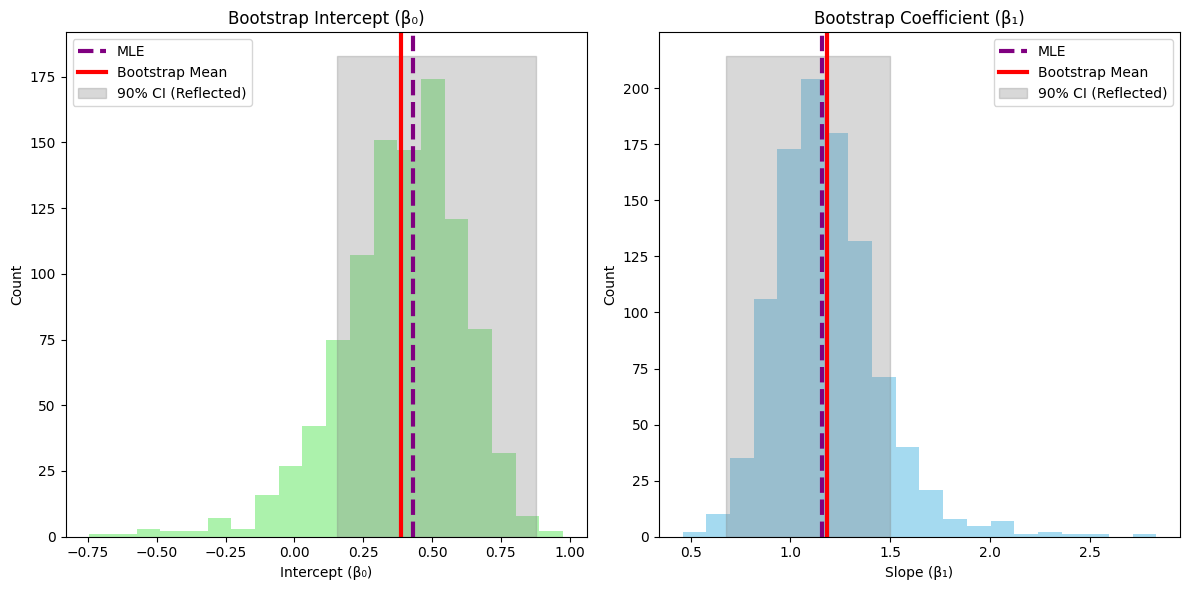

In [26]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import poisson
import matplotlib.pyplot as plt

# === Load and standardize data ===
file_path = r"C:\Users\fenya\Documents\BEE5850\hw04-FenyaB\data\salamanders.csv"
df = pd.read_csv(file_path, delimiter=',')
df['x_std'] = (df['PCTCOVER'] - df['PCTCOVER'].mean()) / df['PCTCOVER'].std()
x = df['x_std'].values
y = df['SALAMAN'].values
n = len(y)

# Poisson log-likelihood
def poisson_loglik(theta, y, x):
    beta_0, beta_1 = theta
    lambd = np.exp(beta_0 + beta_1 * x)
    return -np.sum(poisson.logpmf(y, lambd))

def fit_poisson(x, y):
    result = minimize(lambda theta: poisson_loglik(theta, y, x), 
                      [-10.0, -50.0], bounds=[(None, None), (None, None)])
    return result.x

# Fit original model
theta_mle = fit_poisson(x, y)
beta_0_mle, beta_1_mle = theta_mle

# Bootstrap function
def salamander_bootstrap(x, y, nsamp):
    intercepts = []
    coefficients = []
    n = len(y)

    for i in range(nsamp):
        idx = np.random.randint(0, n, n)
        x_b, y_b = x[idx], y[idx]
        try:
            theta_b = fit_poisson(x_b, y_b)
            intercepts.append(theta_b[0])
            coefficients.append(theta_b[1])
        except:
            continue

    return np.array(intercepts), np.array(coefficients)

n_boot = 1000
np.random.seed(42)
boot_beta_0, boot_beta_1 = salamander_bootstrap(x, y, n_boot)

# Means & Biases
mean_beta_0 = np.mean(boot_beta_0)
mean_beta_1 = np.mean(boot_beta_1)
bias_beta_0 = beta_0_mle - mean_beta_0
bias_beta_1 = beta_1_mle - mean_beta_1

# 90% Confidence Intervals
# Reflected (basic bootstrap)
ci_beta_0_reflected = 2 * beta_0_mle - np.quantile(boot_beta_0, [0.95, 0.05])
ci_beta_1_reflected = 2 * beta_1_mle - np.quantile(boot_beta_1, [0.95, 0.05])

# Percentile (nonparametric bootstrap)
ci_beta_0_percentile = np.quantile(boot_beta_0, [0.05, 0.95])
ci_beta_1_percentile = np.quantile(boot_beta_1, [0.05, 0.95])

print("\n--- Bootstrap Summary ---")
print("MLE β₀: ", round(beta_0_mle, 4))
print("  Bias: ", round(bias_beta_0, 4))
print("  90% Confidence Interval (Reflected): (", round(ci_beta_0_reflected[0], 4), ", ", round(ci_beta_0_reflected[1], 4), ")")
print("  90% Confidence Interval (Percentile): (", round(ci_beta_0_percentile[0], 4), ", ", round(ci_beta_0_percentile[1], 4), ")")

print("\nMLE β₁: ", round(beta_1_mle, 4))
print("  Bias: ", round(bias_beta_1, 4))
print("  90% Confidence Interval (Reflected): (", round(ci_beta_1_reflected[0], 4), ", ", round(ci_beta_1_reflected[1], 4), ")")
print("  90% Confidence Interval (Percentile): (", round(ci_beta_1_percentile[0], 4), ", ", round(ci_beta_1_percentile[1], 4), ")")

plt.figure(figsize=(12, 6))

# Histogram for β₀
plt.subplot(1, 2, 1)
plt.hist(boot_beta_0, bins=20, alpha=0.75, color='lightgreen')
plt.axvline(beta_0_mle, color='purple', linewidth=3, linestyle='--', label='MLE')
plt.axvline(mean_beta_0, color='red', linewidth=3, linestyle='-', label='Bootstrap Mean')
plt.fill_betweenx([0, plt.ylim()[1]], ci_beta_0_reflected[0], ci_beta_0_reflected[1], color='gray', alpha=0.3, label='90% CI (Reflected)')
plt.xlabel("Intercept (β₀)")
plt.ylabel("Count")
plt.title("Bootstrap Intercept (β₀)")
plt.legend()

# Histogram for β₁
plt.subplot(1, 2, 2)
plt.hist(boot_beta_1, bins=20, alpha=0.75, color='skyblue')
plt.axvline(beta_1_mle, color='purple', linewidth=3, linestyle='--', label='MLE')
plt.axvline(mean_beta_1, color='red', linewidth=3, linestyle='-', label='Bootstrap Mean')
plt.fill_betweenx([0, plt.ylim()[1]], ci_beta_1_reflected[0], ci_beta_1_reflected[1], color='gray', alpha=0.3, label='90% CI (Reflected)')
plt.xlabel("Slope (β₁)")
plt.ylabel("Count")
plt.title("Bootstrap Coefficient (β₁)")
plt.legend()

plt.tight_layout()
plt.show()